# 1. Preparação do Ambiente de Análise

In [10]:
# Instalação das dependências
!pip install kagglehub jupter

# Carregamento das bibliotecas
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download da base de dados
path =  kagglehub.dataset_download("namespaiva/base-varejo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'base-varejo' dataset.
Path to dataset files: /kaggle/input/base-varejo


# 2. Carregamento dos Dados

In [11]:
# Construção do caminho e leitura do arquivo
csv_file_name = 'Base Varejo.csv'
file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(file_path, sep=";", encoding="utf-8")

# 3. Visualização e Tratamento dos Dados

## Visualização inicial dos dados



In [12]:
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


## Convertendo a coluna DATA para o tipo datetime

In [13]:
# Convertendo a coluna DATA de object para o tipo datetime
df["DATA"] = pd.to_datetime(df["DATA"], format="%d/%m/%Y", errors="coerce")

# Verificação de datas inválidas após a conversão
datas_invalidas = df["DATA"].isna().sum()

print("Quantidade de datas inválidas:", datas_invalidas)
print("Tipo da coluna DATA:", df["DATA"].dtype)
print("Data inicial:", df["DATA"].min())
print("Data final:", df["DATA"].max())

Quantidade de datas inválidas: 0
Tipo da coluna DATA: datetime64[ns]
Data inicial: 2019-01-04 00:00:00
Data final: 2022-12-08 00:00:00


In [14]:
# Verificação após a conversão
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   DATA         830000 non-null  datetime64[ns]
 1   CO_ID        830000 non-null  int64         
 2   CL_ID        830000 non-null  int64         
 3   CL_GENERO    830000 non-null  object        
 4   CL_EC        830000 non-null  int64         
 5   CL_FHL       830000 non-null  int64         
 6   CL_SEG       830000 non-null  object        
 7   PR_ID        830000 non-null  int64         
 8   PR_CAT       830000 non-null  object        
 9   PR_NOME      830000 non-null  object        
 10  Unnamed: 10  0 non-null       float64       
 11  Unnamed: 11  0 non-null       float64       
 12  Unnamed: 12  0 non-null       float64       
 13  Unnamed: 13  0 non-null       float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(4)
memory usage: 88.7+ MB


## Executando a limpeza de Valores Nulos
Como foram identificadas colunas vazias, abaixo segue o tratamento desses valores

In [15]:
# Fazendo a limpeza de colunas vazias

# Identificação das colunas completamente vazias
colunas_vazias = df.columns[df.isnull().all()].tolist()

print("Colunas totalmente vazias:", colunas_vazias)

# Removendo as colunas vazias
if colunas_vazias:
    df.drop(columns=colunas_vazias, inplace=True)

print("Dimensão após a remoção:", df.shape)


Colunas totalmente vazias: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
Dimensão após a remoção: (830000, 10)


In [16]:
# Verificação da estrutura após a limpeza
print("Colunas restantes:")
print(df.columns.tolist())

display(df.head())

Colunas restantes:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME']


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


Resumo da estrutura e dos tipos de dados da base

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       830000 non-null  datetime64[ns]
 1   CO_ID      830000 non-null  int64         
 2   CL_ID      830000 non-null  int64         
 3   CL_GENERO  830000 non-null  object        
 4   CL_EC      830000 non-null  int64         
 5   CL_FHL     830000 non-null  int64         
 6   CL_SEG     830000 non-null  object        
 7   PR_ID      830000 non-null  int64         
 8   PR_CAT     830000 non-null  object        
 9   PR_NOME    830000 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 63.3+ MB


Tratando valores nulos

In [ ]:
# Verificando a presença de valores nulos na base de dados
df.isnull().sum()

,0
DATA,0
CO_ID,0
CL_ID,0
CL_GENERO,0
CL_EC,0
CL_FHL,0
CL_SEG,0
PR_ID,0
PR_CAT,0
PR_NOME,0


In [18]:
# Verificando textos vazios ou compostos somente por espaços
colunas_texto = df.select_dtypes(include="object").columns

for coluna in colunas_texto:
    qtd_vazios = df[coluna].str.strip().eq("").sum()
    print(f"{coluna}: {qtd_vazios} textos vazios")

CL_GENERO: 0 textos vazios
CL_SEG: 0 textos vazios
PR_CAT: 0 textos vazios
PR_NOME: 0 textos vazios


Validando o tratamento de valores nulos

In [19]:
# Padronização e tratamento preventivo de categorias vazias

# Removendo espaços no início e no final das categorias
df["PR_CAT"] = df["PR_CAT"].str.strip()

# Convertendo textos vazios em valores nulos
df["PR_CAT"] = df["PR_CAT"].replace("", np.nan)

# Preenchendo categorias nulas com "Sem Categoria"
df["PR_CAT"] = df["PR_CAT"].fillna("Sem Categoria")

# Validação do tratamento
print("Categorias nulas após o tratamento:", df["PR_CAT"].isnull().sum())
print("Categorias vazias após o tratamento:", df["PR_CAT"].eq("").sum())
print("\nCategorias existentes:")
print(df["PR_CAT"].value_counts())

Categorias nulas após o tratamento: 0
Categorias vazias após o tratamento: 0

Categorias existentes:
PR_CAT
ALIMENTOS     434767
HIGIENE       155574
LIMPEZA       145754
BEBIDAS        43299
PET            32399
ACESSORIOS     14557
#N/D            3650
Name: count, dtype: int64


## Executando a limpeza de Valores Duplicados

In [20]:
# Verificando a existência de registros duplicados
df.duplicated().sum()

np.int64(96553)

Como foram identificadas duplicatas, abaixo segue o tratamento desses valores

In [21]:
# Visualizando as linhas envolvidas em duplicações
duplicatas = df[df.duplicated(keep=False)]

print("Total de linhas envolvidas em duplicações:", len(duplicatas))
display(duplicatas.sort_values(["CO_ID", "PR_ID"]).head(20))

Total de linhas envolvidas em duplicações: 184330


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
40,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
7,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE
46,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE
14,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA
19,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA
22,2019-02-01,1000,534,M,4,1,C,69,BEBIDAS,REFRIGERANTE LIMaO
49,2019-02-01,1000,534,M,4,1,C,69,BEBIDAS,REFRIGERANTE LIMaO
15,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE
50,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE


In [22]:
# Removendo registros completamente idênticos
registros_antes = len(df)

df.drop_duplicates(inplace=True)

registros_depois = len(df)

print("Registros antes da limpeza:", registros_antes)
print("Duplicatas removidas:", registros_antes - registros_depois)
print("Registros após a limpeza:", registros_depois)
print("Duplicatas restantes após o tratamento:", df.duplicated().sum())

Registros antes da limpeza: 830000
Duplicatas removidas: 96553
Registros após a limpeza: 733447
Duplicatas restantes após o tratamento: 0


# 4. Estatíticas e Agrupamentos

## Estatísticas do número de filhos

In [23]:
# Verificando possíveis inconsistências no número de filhos por cliente
filhos_por_cliente = df.groupby("CL_ID")["CL_FHL"].nunique()
clientes_inconsistentes = (filhos_por_cliente > 1).sum()

print("Clientes com mais de um valor registrado para número de filhos:", clientes_inconsistentes)

Clientes com mais de um valor registrado para número de filhos: 0


In [24]:
# Estatística do número de filhos por clientes

clientes_unicos = df[["CL_ID", "CL_FHL"]].drop_duplicates(subset="CL_ID")

filhos = clientes_unicos["CL_FHL"]

modas = filhos.mode().tolist()

estatisticas_filhos = pd.Series({
    "Contagem de clientes": filhos.count(),
    "Média": filhos.mean(),
    "Mediana": filhos.median(),
    "Desvio padrão": filhos.std(),
    "Moda": modas,
    "Máximo": filhos.max(),
    "Mínimo": filhos.min()
})

print("Estatísticas do número de filhos por cliente:")
display(estatisticas_filhos)

Estatísticas do número de filhos por cliente:


,0
Contagem de clientes,1000
Média,1.136
Mediana,0.0
Desvio padrão,1.41333
Moda,[0]
Máximo,4
Mínimo,0


## Validando a regra do identificador da compra

In [25]:
# Validando a regra de negócio do identificador da compra

validacao_compra = df.groupby("CO_ID").agg(
    quantidade_clientes=("CL_ID", "nunique"),
    quantidade_datas=("DATA", "nunique"),
    quantidade_itens=("PR_ID", "count"))

compras_inconsistentes = validacao_compra[
    (validacao_compra["quantidade_clientes"] > 1) |
    (validacao_compra["quantidade_datas"] > 1)]

print("Quantidade de compras distintas:", df["CO_ID"].nunique())
print("Compras associadas a mais de um cliente ou data:", len(compras_inconsistentes))

display(validacao_compra.head())

Quantidade de compras distintas: 18471
Compras associadas a mais de um cliente ou data: 0


,quantidade_clientes,quantidade_datas,quantidade_itens
CO_ID,,,
1000,1,1,46
1040,1,1,15
1078,1,1,63
1082,1,1,62
1103,1,1,6


## 1ª Agrupamento: comportamento de compras por gênero

In [26]:
# Comportamento de compras por gênero

agrupamento_genero = (df.groupby("CL_GENERO").agg(
          clientes=("CL_ID", "nunique"),
          compras=("CO_ID", "nunique"),
          itens=("PR_ID", "count"))
      .sort_values("compras", ascending=False))

agrupamento_genero["itens_por_compra"] =(agrupamento_genero["itens"]/agrupamento_genero["compras"]).round(2)

display(agrupamento_genero)

,clientes,compras,itens,itens_por_compra
CL_GENERO,,,,
F,519,9615,382427,39.77
M,481,8856,351020,39.64


## 2º Agrupamento: categoria e segmento

In [27]:
# Quantidade de itens por categoria e segmento

agrupamento_categoria_segmento = pd.pivot_table(df,
    index="PR_CAT",
    columns="CL_SEG",
    values="PR_ID",
    aggfunc="count",
    fill_value=0)

agrupamento_categoria_segmento["TOTAL"] = (agrupamento_categoria_segmento.sum(axis=1))

agrupamento_categoria_segmento = (agrupamento_categoria_segmento.sort_values("TOTAL", ascending=False))

display(agrupamento_categoria_segmento)

CL_SEG,A,B,C,TOTAL
PR_CAT,,,,
ALIMENTOS,31118,245501,107578,384197
HIGIENE,11326,87943,38433,137702
LIMPEZA,10460,82063,36109,128632
BEBIDAS,3166,24363,10735,38264
PET,2303,18406,7844,28553
ACESSORIOS,1043,8165,3663,12871
#N/D,261,2064,903,3228


# 5. Evolução temporal das vendas

In [28]:
# Agrupamento das vendas por mês
evolucao_mensal = (df.assign(MES=df["DATA"].dt.to_period("M")).groupby("MES").agg(compras=("CO_ID", "nunique"),itens=("PR_ID", "count")).reset_index())

# Conversão para timestamp, necessária para o gráfico
evolucao_mensal["MES"] = evolucao_mensal["MES"].dt.to_timestamp()

display(evolucao_mensal.head())
display(evolucao_mensal.tail())

,MES,compras,itens
0,2019-01-01,171,6492
1,2019-02-01,402,16153
2,2019-03-01,257,9835
3,2019-04-01,410,16255
4,2019-05-01,711,28115


,MES,compras,itens
43,2022-08-01,273,11224
44,2022-09-01,35,1297
45,2022-10-01,59,2373
46,2022-11-01,155,6192
47,2022-12-01,313,13204


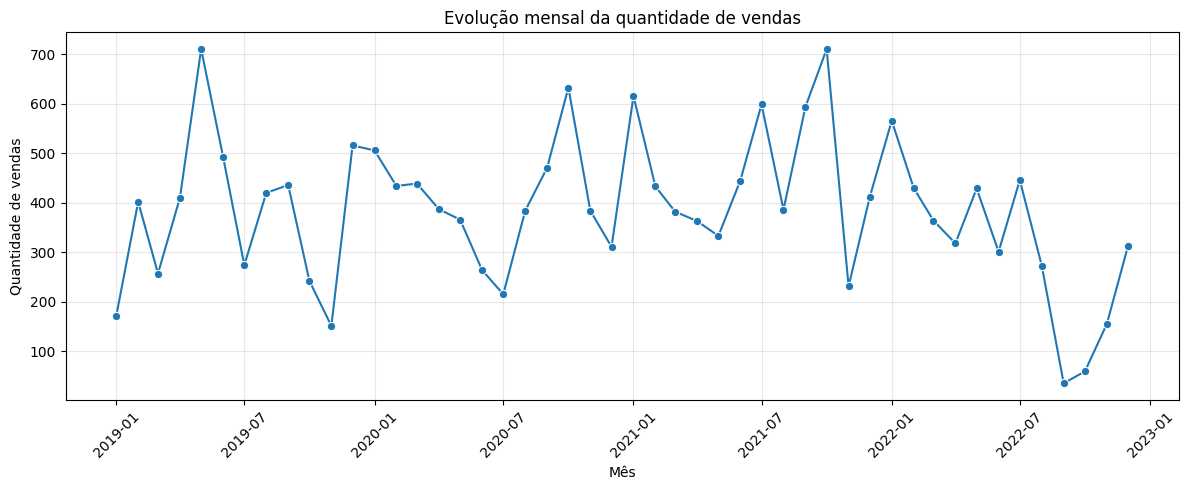

In [29]:
# Gráfico da quantidade mensal de vendas

plt.figure(figsize=(12, 5))

sns.lineplot(data=evolucao_mensal, x="MES", y="compras", marker="o")

plt.title("Evolução mensal da quantidade de vendas")
plt.xlabel("Mês")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Identificação dos meses de maior e menor movimento

In [30]:
# Meses com maior e menor quantidade de vendas

mes_maior = evolucao_mensal.loc[evolucao_mensal["compras"].idxmax()]

mes_menor = evolucao_mensal.loc[evolucao_mensal["compras"].idxmin()]

print("Mês com mais vendas:", mes_maior["MES"].strftime("%m/%Y"), "-", mes_maior["compras"])

print("Mês com menos vendas:", mes_menor["MES"].strftime("%m/%Y"), "-", mes_menor["compras"])

Mês com mais vendas: 05/2019 - 711
Mês com menos vendas: 09/2022 - 35


# 6. Exportação da base tratada

In [31]:
# Exportando a base limpa

nome_arquivo_saida = "Varejo_limpo.csv"

df.to_csv(
    nome_arquivo_saida,
    index=False,
    sep=";",
    encoding="utf-8-sig",
    date_format="%d/%m/%Y")

print("Arquivo exportado:", nome_arquivo_saida)
print("Dimensão exportada:", df.shape)

Arquivo exportado: Varejo_limpo.csv
Dimensão exportada: (733447, 10)


# 7. Download do arquivo

In [33]:
# Download da base tratada
from google.colab import files

files.download(nome_arquivo_saida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>